In [28]:
from utils import censoring_before_t, create_new_dataset, create_surv_data
from lifelines import KaplanMeierFitter

34.0 % of the data has an event


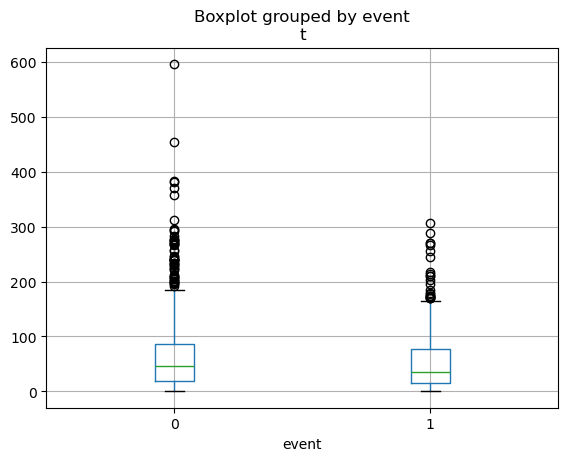

In [29]:
import numpy as np
import pandas as pd
from lifelines import WeibullAFTFitter
import matplotlib.pyplot as plt

n = 1000

data = create_surv_data(shape_weibull=1,   # constant hazard
                        scale_weibull_base=10000, 
                        rate_censoring=0.01,  
                        b_bloodp=-0.405, 
                        b_diab=-0.4, 
                        b_age=-0.05, 
                        b_bmi=-0.01, 
                        b_kreat=-0.2,
                        n=n)

data.boxplot(column='t', by='event', grid=True)
plt.show()

In [30]:
# cutpoint for the time t
t = 150
data_bi = create_new_dataset(data,t)
data_bi['event'].value_counts(normalize=True)

event
0    0.691
1    0.309
Name: proportion, dtype: float64

In [31]:
data_bi.describe()

,bmi,blood_pressure,kreatinkinase,diabetes,age,t,event
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.0,1000.000000
mean,25.096660,0.301000,242.182722,0.188000,49.391420,150.0,0.309000
std,4.896080,0.458922,310.128039,0.390908,9.832316,0.0,0.462312
min,8.793663,0.000000,30.000000,0.000000,19.923677,150.0,0.000000
25%,21.762048,0.000000,78.048474,0.000000,42.707458,150.0,0.000000
50%,25.126503,0.000000,149.445460,0.000000,49.600497,150.0,0.000000
75%,28.239719,1.000000,288.882875,0.000000,55.872299,150.0,1.000000
max,44.263657,1.000000,3421.206459,1.000000,82.430930,150.0,1.000000


In [32]:
data_bi

,bmi,blood_pressure,kreatinkinase,diabetes,age,t,event
0,27.483571,0,108.939308,0,69.203675,150,0
1,24.308678,0,69.954400,0,37.771050,150,0
2,28.238443,0,204.215235,0,50.712537,150,0
3,32.615149,1,567.051680,0,37.064924,150,0
4,23.829233,0,30.000000,0,43.043051,150,0
...,...,...,...,...,...,...,...
995,23.594499,0,77.496655,0,68.205439,150,0
996,33.988433,0,44.558331,0,44.336054,150,0
997,28.204214,0,52.350191,0,58.316168,150,1
998,22.144105,0,91.176490,0,52.094701,150,0


In [33]:
# Kaplan-Meier-Schätzung für Zensierverteilung
kmf = KaplanMeierFitter()
kmf.fit(data['t'], event_observed=1-data['event'])
censoring_prob = 1 - kmf.survival_function_at_times([t]).values[0]
print(censoring_prob)

# IPC-Gewichte 
data_bi['ipc_weight'] = 1 / censoring_prob
data_bi.loc[data['event'] == 0, 'ipc_weight'] = 0
data_bi['ipc_weight'] = data_bi['ipc_weight'] / n

data_bi

0.7789396210323972


,bmi,blood_pressure,kreatinkinase,diabetes,age,t,event,ipc_weight
0,27.483571,0,108.939308,0,69.203675,150,0,0.000000
1,24.308678,0,69.954400,0,37.771050,150,0,0.000000
2,28.238443,0,204.215235,0,50.712537,150,0,0.000000
3,32.615149,1,567.051680,0,37.064924,150,0,0.000000
4,23.829233,0,30.000000,0,43.043051,150,0,0.000000
...,...,...,...,...,...,...,...,...
995,23.594499,0,77.496655,0,68.205439,150,0,0.000000
996,33.988433,0,44.558331,0,44.336054,150,0,0.000000
997,28.204214,0,52.350191,0,58.316168,150,1,0.001284
998,22.144105,0,91.176490,0,52.094701,150,0,0.000000


In [26]:
data_bi['ipc_weight'].sum()

0.4364908278120043